In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
import os

# Data Preparation

In [2]:
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Rename columns to remove spaces
df = df.rename(columns={'Ward ID': 'Ward_ID'})

# Create lag features
def create_lag_features(df, lag_periods=[1, 2, 3]):
    """
    Create lag features for crime density
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time series data
    lag_periods : list
        List of lag periods to create
    Returns:
    --------
    pandas DataFrame with added lag features
    """
    # Sort the dataframe by Ward_ID, Year, and Month_Num
    df = df.sort_values(['Ward_ID', 'Year', 'Month_Num'])
    
    # Create lag features for each ward separately
    for ward in df['Ward_ID'].unique():
        ward_mask = df['Ward_ID'] == ward
        for lag in lag_periods:
            df.loc[ward_mask, f'Crime_Density_Lag_{lag}'] = df.loc[ward_mask, 'Monthly_Crime_Density'].shift(lag)# for each lag period, shifting the crime density values by that many periods.
    
    return df

# Create lag features
df_with_lags = create_lag_features(df)

# Encode Ward_ID
le = LabelEncoder()
df_with_lags['Ward_ID_Encoded'] = le.fit_transform(df_with_lags['Ward_ID'])

# Binning target variable into 3 categories (low, mid, high crime density)
df_with_lags['Crime_Density_Level'] = pd.qcut(df_with_lags['Monthly_Crime_Density'], q=3, labels=[0, 1, 2])

# Defining the features
lag_features = [f'Crime_Density_Lag_{lag}' for lag in [1, 2, 3]]
features = ['Ward_ID_Encoded', 'Year', 'Month_Num'] + lag_features
target = 'Crime_Density_Level'

# Train-test split
df_train = df_with_lags[df_with_lags['Year'] <= 2024]
df_test = df_with_lags[df_with_lags['Year'] > 2024]

# Drop rows with NaN values in any of the features
df_train = df_train.dropna(subset=features + [target])
df_test = df_test.dropna(subset=features + [target])

X_train = df_train[features]
y_train = df_train[target].astype(int)
X_test = df_test[features]
y_test = df_test[target].astype(int)

In [13]:
# Print the dataframe with lags
print("DataFrame with Lags:")
print(df_with_lags)
print("\nDataFrame Shape:", df_with_lags.shape)

# Print shapes of training and test data
print("\nTraining Data Shape:")
print("X_train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

print("\nTest Data Shape:")
print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

# Optional: Print first few rows of training and test data
print("\nFirst few rows of X_train_scaled:")
print(pd.DataFrame(X_train_scaled, columns=features).head())

print("\nFirst few rows of y_train:")
print(pd.DataFrame(y_train).head())
# seeing the final dataframe and ensuring the test set data is large enough to be statistically significant

DataFrame with Lags:
         Ward_ID      Month  Monthly_Burglaries     Ward Name  Ward_Area  \
0      E05000026 2022-03-01                   7         Abbey   1.281178   
1      E05000026 2022-04-01                   6         Abbey   1.281178   
2      E05000026 2022-05-01                   2         Abbey   1.281178   
3      E05000026 2022-06-01                   3         Abbey   1.281178   
4      E05000026 2022-07-01                   5         Abbey   1.281178   
...          ...        ...                 ...           ...        ...   
22820  E05014119 2024-10-01                   1  West Dulwich   1.483496   
22821  E05014119 2024-11-01                   2  West Dulwich   1.483496   
22822  E05014119 2024-12-01                   4  West Dulwich   1.483496   
22823  E05014119 2025-01-01                   3  West Dulwich   1.483496   
22824  E05014119 2025-02-01                   4  West Dulwich   1.483496   

       Monthly_Crime_Density  Year  Month_Num  Crime_Density_Lag_1

# Logistic Regression Modelling and Evaluation

In [3]:
# Initialize the logistic regression model.
# Initialize the StandardScaler
# Scale features(necessary for machine learning techniques)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_reg = LogisticRegression(max_iter=50000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_prob = log_reg.predict_proba(X_test_scaled)

# Evaluate model
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("ROC AUC Score:", auc)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.6718878812860676
ROC AUC Score: 0.8416588711374585

Confusion Matrix:
[[291  91  11]
 [129 240  81]
 [  9  77 284]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.74      0.71       393
           1       0.59      0.53      0.56       450
           2       0.76      0.77      0.76       370

    accuracy                           0.67      1213
   macro avg       0.67      0.68      0.68      1213
weighted avg       0.67      0.67      0.67      1213


## Feature importance visualization

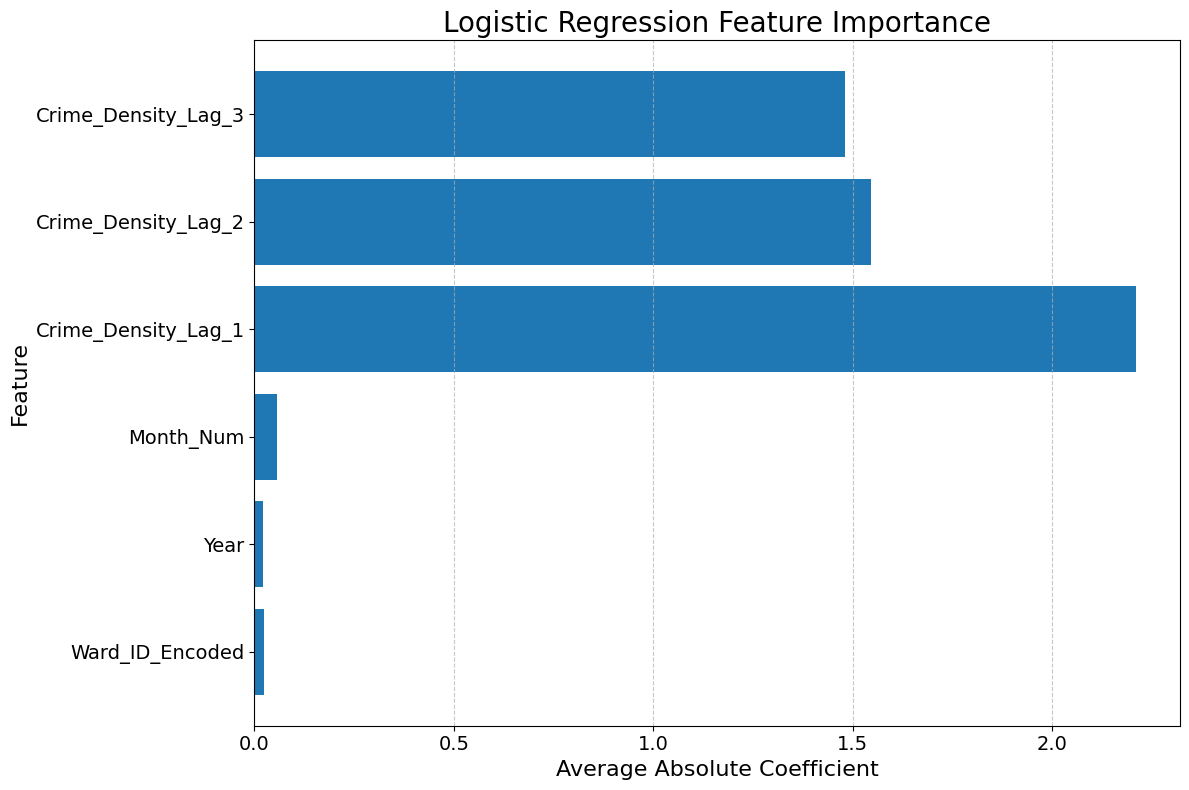

In [4]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': np.mean(np.abs(log_reg.coef_), axis=0)  # Average absolute coefficient across classes
})

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])

# Increasing font sizes
plt.title('Logistic Regression Feature Importance', fontsize=20)
plt.xlabel('Average Absolute Coefficient', fontsize=16)
plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Adding grid for better readability
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## ROC curve

C:\Users\20232755\AppData\Local\Temp\ipykernel_34624\1993583471.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


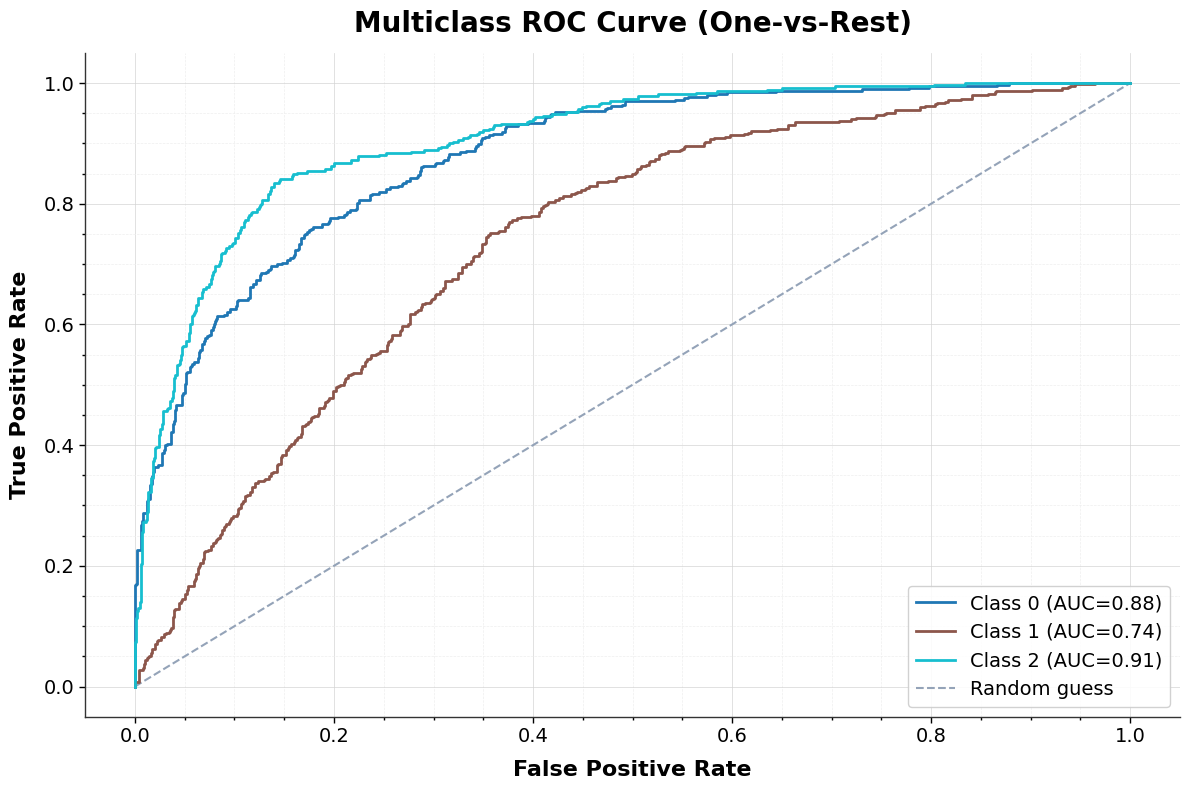

In [5]:
classes = np.unique(y_test)
n_classes = len(classes)

# Initializing the plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='#d4d4d4', zorder=0)
ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='#efefef', zorder=0)

# Colors for each class
colors = plt.cm.get_cmap('tab10', n_classes)

# Plot ROC for each class
for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    
    ax.plot(fpr, tpr,
            color=colors(i),
            linestyle='-',
            linewidth=2,
            label=f"Class {classes[i]} (AUC={auc:.2f})",
            zorder=3)

# Diagonal reference line (random guess = 0.5)
ax.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', linewidth=1.5, label="Random guess", zorder=2)

# Plot settings
ax.set_xlabel("False Positive Rate", fontsize=16, labelpad=10, fontweight='bold')
ax.set_ylabel("True Positive Rate", fontsize=16, labelpad=10, fontweight='bold')
ax.set_title("Multiclass ROC Curve (One-vs-Rest)", fontsize=20, pad=15, fontweight='bold')
ax.set_xticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(np.arange(0, 1.05, 0.05), minor=True)
ax.set_yticks(np.arange(0, 1.05, 0.05), minor=True)
ax.tick_params(axis='both', which='major', labelsize=14, direction='out', length=4, width=1)
ax.tick_params(axis='both', which='minor', direction='out', length=2, width=1, labelsize=0)
ax.legend(loc="lower right", framealpha=0.9, edgecolor='#CCCCCC', fontsize=14)
ax.set_facecolor('white')

# Removing top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

fig.tight_layout()
plt.show()


# Cross-Validation with 5 Folds

In [9]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
print(f"Accuracy Cross-Validation Scores: {scores}")

Accuracy Cross-Validation Scores: [0.70431211 0.67984596 0.6508344  0.66931964 0.61976893]


# Hyperparementer Tuning on max_iter

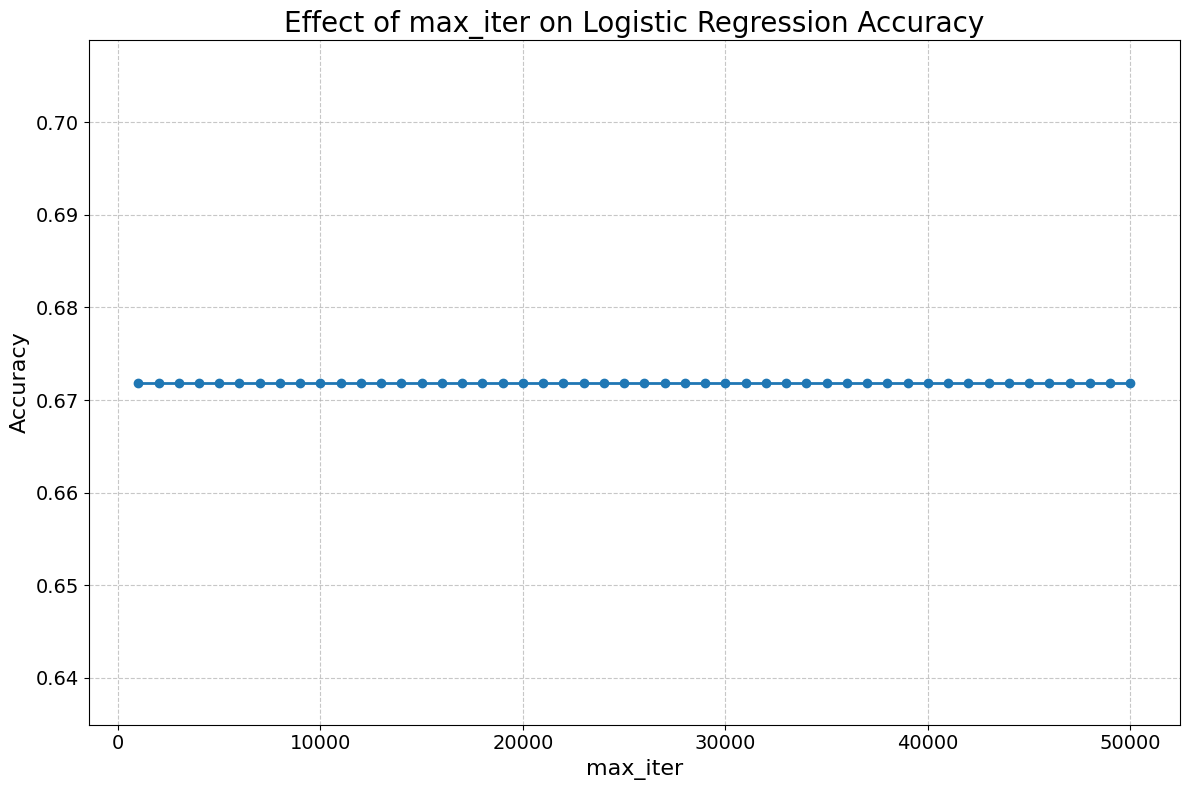

In [8]:
# Define the range for max_iter values
max_iter_values = np.arange(1000, 50001, 1000)
accuracy_list = []

# Loop through different max_iter values and record the accuracy
# The default solver is used because lbfgs is more efficient and faster for multi-class logistic regression
for max_iter in max_iter_values:
    log_reg = LogisticRegression(max_iter=max_iter, solver='lbfgs')
    log_reg.fit(X_train_scaled, y_train)  # Use scaled training data
    y_pred = log_reg.predict(X_test_scaled)  # Use scaled test data
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)
    
plt.figure(figsize=(12, 8))
plt.plot(max_iter_values, accuracy_list, marker='o', linestyle='-', linewidth=2)

# Increase font sizes
plt.title('Effect of max_iter on Logistic Regression Accuracy', fontsize=20)
plt.xlabel('max_iter', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# As a result the value of max_iter parameter doesnt have any effect on improving the accuracy for logistic regression.